In [1]:
import os

dataset_path = '../dataset'

for folder in os.listdir(dataset_path):
    sub = os.path.join(dataset_path, folder)
    if os.path.isdir(sub):
        for cls in os.listdir(sub):
            cls_path = os.path.join(sub, cls)
            if os.path.isdir(cls_path):
                print(f"{folder}/{cls}: {len(os.listdir(cls_path))} images")

test/autistic: 100 images
test/non_autistic: 100 images
train/autistic: 1263 images
train/non_autistic: 1263 images


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Train generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2   # 20% of train data used for validation
)

# Test generator (no augmentation, only rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train data
train_generator = train_datagen.flow_from_directory(
    '../dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation data
val_generator = train_datagen.flow_from_directory(
    '../dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    '../dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Classes:", train_generator.class_indices)

Found 2022 images belonging to 2 classes.
Found 504 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Classes: {'autistic': 0, 'non_autistic': 1}


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Fully connected layers
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')  # 2 classes: autistic, non_autistic
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\DELL\Desktop\autism-project\autism-spectrum-pre-predictor\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,610 (18.42 MB)

 Trainable params: 4,828,610 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# Create models folder if not exists
os.makedirs('../models', exist_ok=True)

# Callbacks
callbacks = [
    ModelCheckpoint(
        '../models/best_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        patience=3,
        factor=0.5,
        verbose=1
    )
]

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

c:\Users\DELL\Desktop\autism-project\autism-spectrum-pre-predictor\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.5495 - loss: 0.7024
Epoch 1: val_accuracy improved from -inf to 0.56746, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 838ms/step - accuracy: 0.5507 - loss: 0.7016 - val_accuracy: 0.5675 - val_loss: 0.8780 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.6896 - loss: 0.5887
Epoch 2: val_accuracy improved from 0.56746 to 0.62500, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 552ms/step - accuracy: 0.6896 - loss: 0.5885 - val_accuracy: 0.6250 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.7192 - loss: 0.5465
Epoch 3: val_accuracy did not improve from 0.62500
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 581ms/step - accuracy: 0.7195 - loss: 0.5462 - val_accuracy: 0.6171 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.7481 - loss: 0.5351
Epoch 4: val_accuracy improved from 0.62500 to 0.64286, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 550ms/step - accuracy: 0.7479 - loss: 0.5350 - val_accuracy: 0.6429 - val_loss: 0.6310 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.7563 - loss: 0.5090
Epoch 5: val_accuracy did not improve from 0.64286
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 543ms/step - accuracy: 0.7561 - loss: 0.5092 - val_accuracy: 0.6389 - val_loss: 0.6422 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.7678 - loss: 0.4816
Epoch 6: val_accuracy improved from 0.64286 to 0.64683, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 554ms/step - accuracy: 0.7678 - loss: 0.4818 - val_accuracy: 0.6468 - val_loss: 0.6546 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.7809 - loss: 0.4923
Epoch 7: val_accuracy improved from 0.64683 to 0.64881, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 539ms/step - accuracy: 0.7808 - loss: 0.4921 - val_accuracy: 0.6488 - val_loss: 0.6271 - learning_rate: 0.0010
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.7791 - loss: 0.4850
Epoch 8: val_accuracy improved from 0.64881 to 0.65278, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 550ms/step - accuracy: 0.7790 - loss: 0.4850 - val_accuracy: 0.6528 - val_loss: 0.6202 - learning_rate: 0.0010
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7801 - loss: 0.4574
Epoch 9: val_accuracy improved from 0.65278 to 0.66865, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 545ms/step - accuracy: 0.7800 - loss: 0.4574 - val_accuracy: 0.6687 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.7925 - loss: 0.4386
Epoch 10: val_accuracy improved from 0.66865 to 0.68056, saving model to ../models/best_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 536ms/step - accuracy: 0.7925 - loss: 0.4387 - val_accuracy: 0.6806 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.7683 - loss: 0.4919
Epoch 11: val_accuracy did not improve from 0.68056

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 538ms/step - accuracy: 0.7684 - loss: 0.4916 - val_accuracy: 0.6508 - val_loss: 0.6683 - learning_rate: 0.0010
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.8303 - loss: 0.3866
Epoch 12: val_accuracy did not improve from 0.68056
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 534ms/step - accuracy: 0.8301 - loss: 0.3869 - val_accuracy: 0.6667 - val_loss: 0.6255 - learning_rate: 5.0000e-04
Epoch 13/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8189 - loss: 0.4096
Epoch 13: val_accuracy did not improve from 0.68056
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 542ms/step - accuracy: 0.8188 - loss: 0.4096

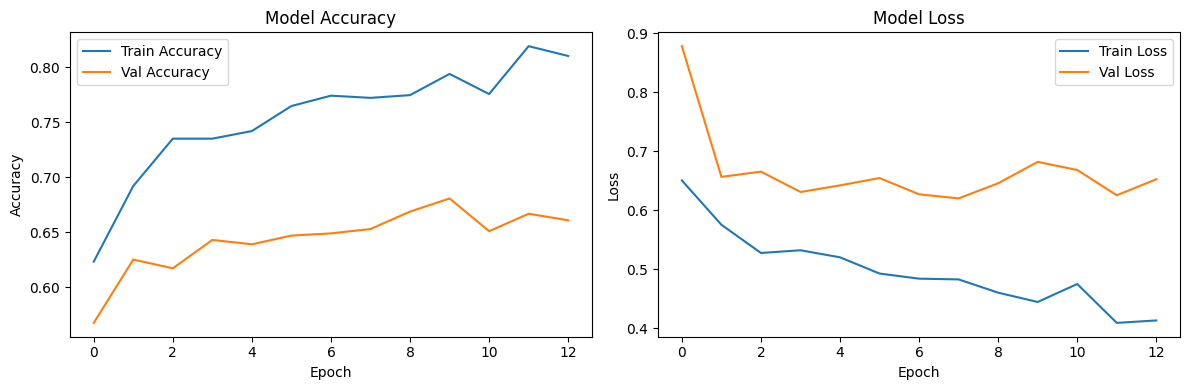

Graph saved to outputs folder!


In [5]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../outputs/training_curves.png')
plt.show()
print("Graph saved to outputs folder!")

In [9]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached pandas-2.3.3-cp39-cp39-win_amd64.whl (11.4 MB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\DELL\Desktop\autism-project\autism-spectrum-pre-predictor\venv\Scripts\python.exe -m pip install --upgrade pip' command.


c:\Users\DELL\Desktop\autism-project\autism-spectrum-pre-predictor\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.8648 - loss: 0.3905

Test Accuracy: 86.50%
Test Loss: 0.3787
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.51      0.48      0.49       100
Non_Autistic       0.50      0.53      0.52       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



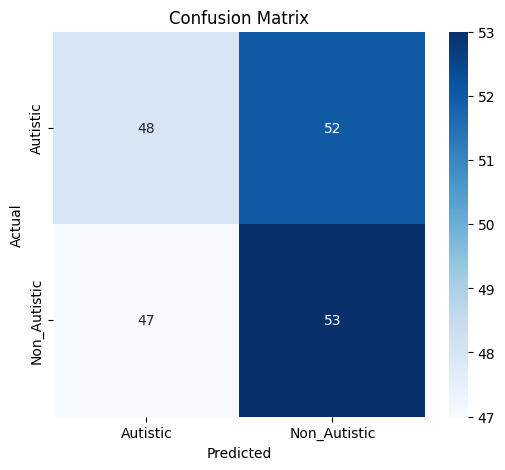

Confusion matrix saved!


In [10]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes,
      target_names=['Autistic', 'Non_Autistic']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Autistic', 'Non_Autistic'],
            yticklabels=['Autistic', 'Non_Autistic'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load ResNet50 with pretrained ImageNet weights
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

# Freeze base model layers
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

# Create final model
transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning model ready!")
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Transfer Learning model ready!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os
#ResNet50
os.makedirs('../models', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        '../models/best_transfer_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        patience=3,
        factor=0.5,
        verbose=1
    )
]

history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

print("Transfer Learning training complete!")

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5193 - loss: 0.7691
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to ../models/best_transfer_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5193 - loss: 0.7686 - val_accuracy: 0.5000 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5323 - loss: 0.6994
Epoch 2: val_accuracy did not improve from 0.50000
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.5324 - loss: 0.6993 - val_accuracy: 0.5000 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5467 - loss: 0.6929
Epoch 3: val_accuracy did not improve from 0.50000
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.5468 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.7643 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5457 - loss: 0.6900
Epoch 4: val_accuracy did not improve from 0.50000

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5460 - loss: 0.6899 - val_accuracy: 0.5000 - val_l

In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Correct data generators for MobileNetV2
train_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # correct preprocessing
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen2 = train_datagen2.flow_from_directory(
    '../dataset/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen2 = train_datagen2.flow_from_directory(
    '../dataset/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_gen2 = test_datagen2.flow_from_directory(
    '../dataset/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# Build MobileNetV2 model
base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

mobile_model = Model(inputs=base.input, outputs=output)
mobile_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 model ready!")
mobile_model.summary()

Found 2022 images belonging to 2 classes.
Found 504 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


C:\Users\DELL\AppData\Local\Temp\ipykernel_5504\3386806077.py:44: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 model ready!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
# Train MobileNetV2:
callbacks2 = [
    ModelCheckpoint(
        '../models/best_mobilenet_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        patience=3,
        factor=0.5,
        verbose=1
    )
]

history2 = mobile_model.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=20,
    callbacks=callbacks2
)

print("MobileNetV2 training complete!")

c:\Users\DELL\Desktop\autism-project\autism-spectrum-pre-predictor\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.6220 - loss: 0.9260
Epoch 1: val_accuracy improved from -inf to 0.65476, saving model to ../models/best_mobilenet_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 818ms/step - accuracy: 0.6229 - loss: 0.9223 - val_accuracy: 0.6548 - val_loss: 0.6834 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.7432 - loss: 0.5196
Epoch 2: val_accuracy did not improve from 0.65476
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 721ms/step - accuracy: 0.7430 - loss: 0.5198 - val_accuracy: 0.6488 - val_loss: 0.6373 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7574 - loss: 0.4970
Epoch 3: val_accuracy improved from 0.65476 to 0.65873, saving model to ../models/best_mobilenet_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 734ms/step - accuracy: 0.7575 - loss: 0.4967 - val_accuracy: 0.6587 - val_loss: 0.6233 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.7541 - loss: 0.4893
Epoch 4: val_accuracy did not improve from 0.65873
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 763ms/step - accuracy: 0.7542 - loss: 0.4893 - val_accuracy: 0.6548 - val_loss: 0.6102 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.7985 - loss: 0.4377
Epoch 5: val_accuracy improved from 0.65873 to 0.72024, saving model to ../models/best_mobilenet_model.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 817ms/step - accuracy: 0.7984 - loss: 0.4378 - val_accuracy: 0.7202 - val_loss: 0.5656 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.7887 - loss: 0.4206
Epoch 6: val_accuracy did not improve from 0.72024
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 824ms/step - accuracy: 0.7885 - loss: 0.4211 - val_accuracy: 0.6964 - val_loss: 0.6114 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.7884 - loss: 0.4205
Epoch 7: val_accuracy did not improve from 0.72024
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 822ms/step - accuracy: 0.7884 - loss: 0.4206 - val_accuracy: 0.6885 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.7979 - loss: 0.4393
Epoch 8: val_accuracy did not improve from 0.72024

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 789ms/step - accuracy: 0.7978 - loss: 0.4393 - val_accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.8721 - loss: 0.3267

Test Accuracy: 87.00%
Test Loss: 0.3464
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 679ms/step

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.63      0.58      0.60       100
Non_Autistic       0.61      0.66      0.63       100

    accuracy                           0.62       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.62      0.62      0.62       200



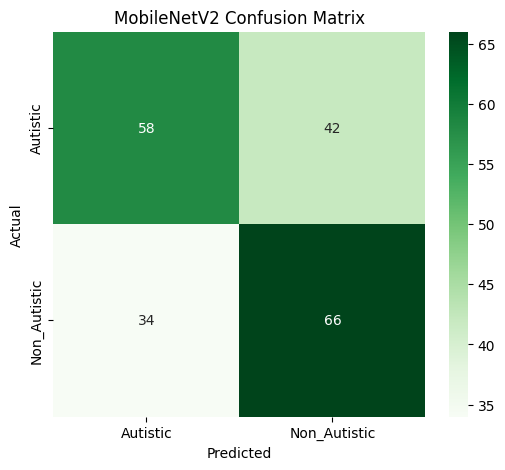

In [15]:
# Evaluate on test data
test_loss2, test_accuracy2 = mobile_model.evaluate(test_gen2)
print(f"\nTest Accuracy: {test_accuracy2*100:.2f}%")
print(f"Test Loss: {test_loss2:.4f}")

# Get predictions
test_gen2.reset()
y_pred2 = mobile_model.predict(test_gen2)
y_pred_classes2 = np.argmax(y_pred2, axis=1)
y_true2 = test_gen2.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true2, y_pred_classes2,
      target_names=['Autistic', 'Non_Autistic']))

# Confusion Matrix
cm2 = confusion_matrix(y_true2, y_pred_classes2)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Autistic', 'Non_Autistic'],
            yticklabels=['Autistic', 'Non_Autistic'])
plt.title('MobileNetV2 Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/mobilenet_confusion_matrix.png')
plt.show()

In [17]:
import tensorflow as tf

# Unfreeze last 20 layers of MobileNetV2
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
history3 = mobile_model.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=10,
    callbacks=callbacks2
)
print("Fine tuning complete!")

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.7102 - loss: 0.5789
Epoch 1: val_accuracy did not improve from 0.72024
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 822ms/step - accuracy: 0.7105 - loss: 0.5786 - val_accuracy: 0.6925 - val_loss: 0.6150 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.7393 - loss: 0.5106
Epoch 2: val_accuracy did not improve from 0.72024
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 773ms/step - accuracy: 0.7391 - loss: 0.5107 - val_accuracy: 0.6984 - val_loss: 0.6489 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.7547 - loss: 0.4916
Epoch 3: val_accuracy did not improve from 0.72024
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 785ms/step - accuracy: 0.7548 - loss: 0.4916 - val_accuracy: 0.6607 - val_loss: 0.7058 - learning_rate: 1.0000e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.7853 - loss: 0.4766
Epoch 4: val_accuracy did not improve from 0.72024

Epoch 4: Redu

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step - accuracy: 0.8499 - loss: 0.3772

FINAL RESULTS SUMMARY
Basic CNN Test Accuracy:       50.5%
MobileNetV2 Test Accuracy:     85.00%


7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 660ms/step

Final Classification Report:
              precision    recall  f1-score   support

    Autistic       0.53      0.46      0.49       100
Non_Autistic       0.53      0.60      0.56       100

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



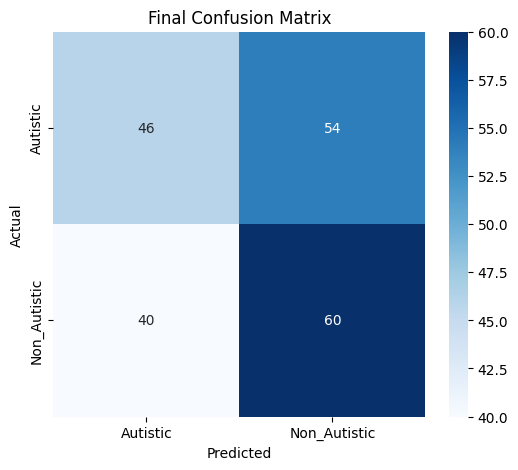


Final model saved to models/final_autism_model.h5 ✅


In [18]:
# Final evaluation on test data
test_loss3, test_accuracy3 = mobile_model.evaluate(test_gen2)
print(f"\n{'='*40}")
print(f"FINAL RESULTS SUMMARY")
print(f"{'='*40}")
print(f"Basic CNN Test Accuracy:       50.5%")
print(f"MobileNetV2 Test Accuracy:     {test_accuracy3*100:.2f}%")
print(f"{'='*40}")

# Final confusion matrix
test_gen2.reset()
y_pred_final = mobile_model.predict(test_gen2)
y_pred_final_classes = np.argmax(y_pred_final, axis=1)
y_true_final = test_gen2.classes

print("\nFinal Classification Report:")
print(classification_report(y_true_final, y_pred_final_classes,
      target_names=['Autistic', 'Non_Autistic']))

# Plot final confusion matrix
cm_final = confusion_matrix(y_true_final, y_pred_final_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Autistic', 'Non_Autistic'],
            yticklabels=['Autistic', 'Non_Autistic'])
plt.title('Final Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/final_confusion_matrix.png')
plt.show()

# Save final model
mobile_model.save('../models/final_autism_model.h5')
print("\nFinal model saved to models/final_autism_model.h5 ✅")

In [19]:
# Save final model
mobile_model.save('../models/final_autism_model.h5')
print("Final model saved! ✅")

Final model saved! ✅
